# Processamento de Sinais I — Aula Prática 3
## Questão 1 — Resposta em frequência e polos/zeros do sistema

Sistema analisado:
$$H(z) = 1 + 0.49z^{-2} + 0.2401z^{-6} - 0.0576z^{-8} - 0.0282z^{-10} - 0.0138z^{-12}$$

Objetivo: calcular a resposta em frequência, obter o diagrama de polos e zeros e comentar os resultados.

## Importar bibliotecas e helpers

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from scipy.io import wavfile
from scipy import signal


def load_calculate_spectrum():
    notebook_path = Path('../tools/calculate_spectrum.ipynb')
    notebook = json.loads(notebook_path.read_text(encoding='utf-8'))

    namespace = {}
    for cell in notebook['cells']:
        if cell.get('cell_type') != 'code':
            continue

        source = ''.join(cell.get('source', []))
        exec(source, namespace)
        if 'calculate_spectrum' in namespace:
            return namespace['calculate_spectrum']

    raise RuntimeError('calculate_spectrum() nao encontrada em ../tools/calculate_spectrum.ipynb')


calculate_spectrum = load_calculate_spectrum()
plt.style.use('seaborn-v0_8-whitegrid')



def to_float_mono(data):
    data = np.asarray(data)
    if data.ndim > 1:
        data = data.mean(axis=1)
    if np.issubdtype(data.dtype, np.integer):
        data = data.astype(np.float64) / np.iinfo(data.dtype).max
    else:
        data = data.astype(np.float64)
    peak = np.max(np.abs(data))
    if peak > 1:
        data = data / peak
    return data



def normalize_audio(audio):
    peak = np.max(np.abs(audio))
    if peak == 0:
        return audio
    return audio / peak



def show_audio(audio, rate, label):
    print(label)
    display(Audio(normalize_audio(audio), rate=rate))



def plot_frequency_response(b, a, title):
    w, h = signal.freqz(b, a, worN=2048)
    plt.figure(figsize=(12, 4))
    plt.plot(w / np.pi, 20 * np.log10(np.maximum(np.abs(h), 1e-8)))
    plt.title(title)
    plt.xlabel('Frequencia normalizada (x pi rad/amostra)')
    plt.ylabel('Magnitude (dB)')
    plt.tight_layout()
    return w, h



def plot_zplane(b, a, title):
    zeros, poles, gain = signal.tf2zpk(b, a)
    theta = np.linspace(0, 2 * np.pi, 512)

    plt.figure(figsize=(6, 6))
    plt.plot(np.cos(theta), np.sin(theta), '--', color='gray', label='Circulo unitario')
    if len(zeros):
        plt.scatter(np.real(zeros), np.imag(zeros), marker='o', facecolors='none', edgecolors='C0', s=100, label='Zeros')
    if len(poles):
        plt.scatter(np.real(poles), np.imag(poles), marker='x', color='C3', s=100, label='Polos')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(title)
    plt.xlabel('Parte real')
    plt.ylabel('Parte imaginaria')
    plt.legend()
    plt.tight_layout()
    return zeros, poles, gain



def design_inverse_fir(b, a, num_taps=129, epsilon=1e-3, n_fft=8192):
    _, H = signal.freqz(b, a, worN=n_fft, whole=True)
    G = np.conj(H) / (np.abs(H) ** 2 + epsilon)
    h = np.fft.ifft(G).real
    h = h[:num_taps]
    h *= np.hamming(num_taps)
    return normalize_audio(h)



def align_signals(reference, estimate):
    corr = signal.correlate(estimate, reference, mode='full')
    lag = np.argmax(corr) - (len(reference) - 1)
    if lag > 0:
        estimate_aligned = estimate[lag:lag + len(reference)]
        reference_aligned = reference[:len(estimate_aligned)]
    else:
        start = -lag
        reference_aligned = reference[start:start + len(estimate)]
        estimate_aligned = estimate[:len(reference_aligned)]
    size = min(len(reference_aligned), len(estimate_aligned))
    return reference_aligned[:size], estimate_aligned[:size], lag



def quality_metrics(reference, estimate):
    reference_aligned, estimate_aligned, lag = align_signals(reference, estimate)
    error = reference_aligned - estimate_aligned
    mse = np.mean(error ** 2)
    snr = 10 * np.log10(np.mean(reference_aligned ** 2) / np.maximum(np.mean(error ** 2), 1e-12))
    corr = np.corrcoef(reference_aligned, estimate_aligned)[0, 1]
    return {'lag': lag, 'mse': mse, 'snr_db': snr, 'corr': corr}


## Definir o sistema e visualizar a resposta em frequência e o diagrama de polos e zeros

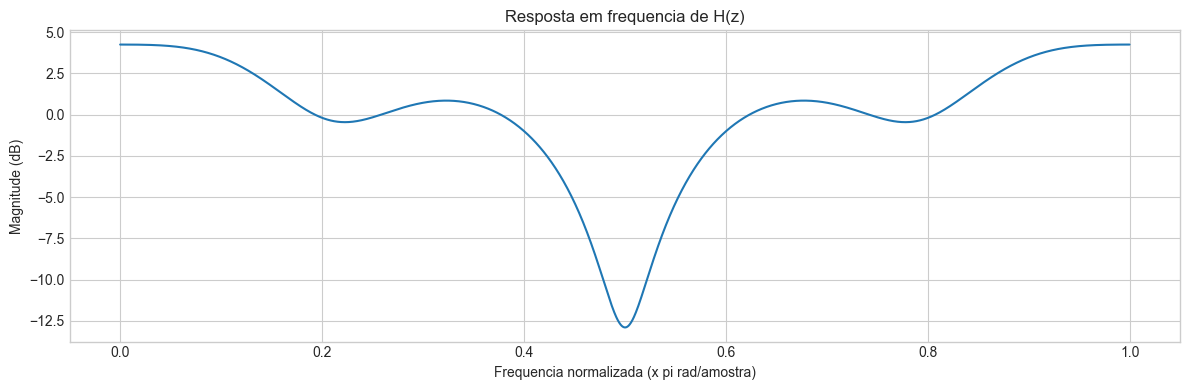

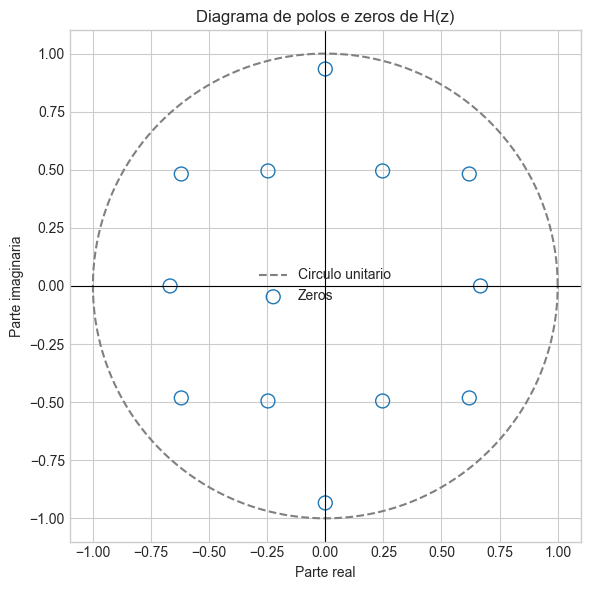

Zeros do sistema:
[-6.19686020e-01+0.48183667j -6.19686020e-01-0.48183667j
 -6.67877806e-01+0.j          1.11022302e-16+0.93359874j
  1.11022302e-16-0.93359874j  6.19686020e-01+0.48183667j
  6.19686020e-01-0.48183667j  6.67877806e-01+0.j
 -2.46663570e-01+0.49488805j -2.46663570e-01-0.49488805j
  2.46663570e-01+0.49488805j  2.46663570e-01-0.49488805j]
Polos do sistema:
[]


In [2]:
b = np.zeros(13)
b[0] = 1
b[2] = 0.49
b[6] = 0.2401
b[8] = -0.0576
b[10] = -0.0282
b[12] = -0.0138
a = np.array([1.0])

plot_frequency_response(b, a, 'Resposta em frequencia de H(z)')
plt.show()

zeros, poles, gain = plot_zplane(b, a, 'Diagrama de polos e zeros de H(z)')
plt.show()

print('Zeros do sistema:')
print(zeros)
print('Polos do sistema:')
print(poles)


## Comentários

Como o denominador é unitário, o sistema é FIR e não possui polos finitos além da origem na implementação em atrasos. O comportamento da resposta em frequência é determinado pelos zeros do numerador.

O diagrama de polos e zeros mostra vários zeros em pares conjugados, o que produz atenuações seletivas em determinadas faixas. A resposta em frequência, portanto, apresenta vales e regiões de ganho mais baixo associados à proximidade desses zeros ao círculo unitário.